In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.tree import export_text
import json
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Smart_irrigation_dataset.csv")
df.head()

,crop_name,soil_type,crop_age_days,day_of_year,temperature_C,humidity_%,rainfall_mm,effective_rainfall_mm,solar_radiation_MJ_m2_day,wind_speed_m_s,...,soil_moisture_%,reference_evapotranspiration_ET0_mm_day,crop_coefficient_Kc,application_efficiency_%,root_zone_depth_m,available_water_content_mm_per_m,irrigation_interval_days,p_fraction,irrigate,irrigation_amount_m3
0,Tomato,Sandy,55,324,19.90,74.79,1.08,0.55,18.94,2.72,...,20.25,2.249,1.050,70.42,0.694,135.58,7,0.387,1,251.6741
1,Wheat,Silty,96,89,19.39,61.01,2.07,1.21,27.04,3.20,...,31.57,2.000,0.544,64.13,0.347,115.47,3,0.300,0,0.0000
2,Maize,Sandy,36,161,30.20,93.53,2.11,1.27,29.09,1.54,...,19.09,2.574,0.946,82.43,0.533,103.85,8,0.536,1,202.6717
3,Tomato,Silty,114,334,20.59,51.75,4.61,3.06,27.12,2.03,...,23.85,2.502,0.630,73.99,1.150,131.45,8,0.562,0,0.0000
4,Tomato,Silty,37,75,36.59,93.87,0.40,0.35,7.68,3.57,...,21.00,2.745,0.915,61.72,1.135,124.15,10,0.405,1,588.5058


In [3]:
SENSOR_COLS = ["soil_moisture_%", "temperature_C", "humidity_%", "rainfall_mm"]
USER_COLS = ["crop_name", "soil_type", "crop_age_days"]
FEATURE_COLS = SENSOR_COLS + USER_COLS

missing = [c for c in FEATURE_COLS + ["irrigate", "irrigation_amount_m3"] if c not in df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes: {missing}")

X = df[FEATURE_COLS].copy()
y_class = df["irrigate"]
y_reg = df["irrigation_amount_m3"]

num_cols = SENSOR_COLS + ["crop_age_days"]
cat_cols = ["crop_name", "soil_type"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", MinMaxScaler()),
                ]
            ),
            num_cols,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            cat_cols,
        ),
    ]
)

print("Numeriques (MinMax):", num_cols)
print("Categorielles (OneHot):", cat_cols)

Numeriques (MinMax): ['soil_moisture_%', 'temperature_C', 'humidity_%', 'rainfall_mm', 'crop_age_days']
Categorielles (OneHot): ['crop_name', 'soil_type']


In [4]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

base_clf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                class_weight="balanced",
            ),
        ),
    ]
)

# Recherche d'hyperparametres: n_estimators et max_depth plus eleves pour gagner en accuracy
param_grid_c = {
    "model__n_estimators": [100, 200, 400],
    "model__max_depth": [6, 10, None],
    "model__min_samples_leaf": [1, 2],
}

grid_c = GridSearchCV(
    base_clf,
    param_grid=param_grid_c,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
grid_c.fit(X_train_c, y_train_c)

clf_pipeline = grid_c.best_estimator_
print("Meilleurs hyperparametres (classification):", grid_c.best_params_)
print(f"Accuracy CV (moyenne {int(grid_c.cv)} folds): {grid_c.best_score_:.4f}")

y_pred_c = clf_pipeline.predict(X_test_c)
acc = accuracy_score(y_test_c, y_pred_c)
print(f"Accuracy (classification - test): {acc:.4f}")
print("Rapport de classification:\n")
print(classification_report(y_test_c, y_pred_c))

Fitting 3 folds for each of 18 candidates, totalling 54 fits


Meilleurs hyperparametres (classification): {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Accuracy CV (moyenne 3 folds): 0.7729
Accuracy (classification - test): 0.7720
Rapport de classification:

              precision    recall  f1-score   support

           0       0.73      0.77      0.75       892
           1       0.81      0.77      0.79      1108

    accuracy                           0.77      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.77      0.77      0.77      2000



In [5]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

base_reg = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

param_grid_r = {
    "model__n_estimators": [100, 200, 400],
    "model__max_depth": [6, 10, None],
    "model__min_samples_leaf": [1, 2],
}

grid_r = GridSearchCV(
    base_reg,
    param_grid=param_grid_r,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
grid_r.fit(X_train_r, y_train_r)

reg_pipeline = grid_r.best_estimator_
print("Meilleurs hyperparametres (regression):", grid_r.best_params_)
print(f"MSE CV (moyenne {int(grid_r.cv)} folds): {-grid_r.best_score_:.4f}")

y_pred_r = reg_pipeline.predict(X_test_r)

mae = mean_absolute_error(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_r)

print(f"MSE (regression / water_amount - test): {mse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2 : {r2:.4f}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Meilleurs hyperparametres (regression): {'model__max_depth': 6, 'model__min_samples_leaf': 2, 'model__n_estimators': 400}
MSE CV (moyenne 3 folds): 41643.9746
MSE (regression / water_amount - test): 43150.7493
MAE : 150.1755
RMSE : 207.7276
R2 : 0.4316


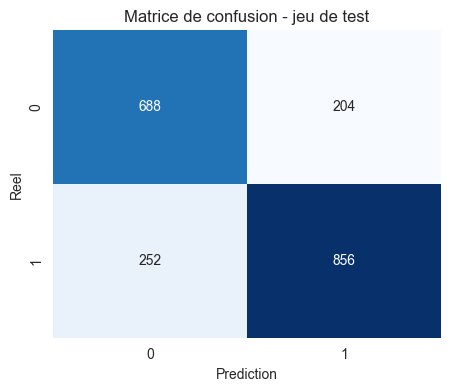

Accuracy Tomato (classification): 0.7761
              precision    recall  f1-score   support

           0       0.74      0.74      0.74       234
           1       0.81      0.80      0.80       311

    accuracy                           0.78       545
   macro avg       0.77      0.77      0.77       545
weighted avg       0.78      0.78      0.78       545

Tomato regression -> MAE: 147.1850, RMSE: 204.9322, R2: 0.4523


In [6]:
sns.set_style("whitegrid")
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matrice de confusion - jeu de test")
plt.xlabel("Prediction")
plt.ylabel("Reel")
plt.show()


mask_tomato_c = X_test_c["crop_name"] == "Tomato"
mask_tomato_r = X_test_r["crop_name"] == "Tomato"

if mask_tomato_c.sum() > 0:
    y_test_tomato = y_test_c[mask_tomato_c]
    y_pred_tomato = clf_pipeline.predict(X_test_c[mask_tomato_c])
    acc_tomato = accuracy_score(y_test_tomato, y_pred_tomato)
    print(f"Accuracy Tomato (classification): {acc_tomato:.4f}")
    print(classification_report(y_test_tomato, y_pred_tomato))
else:
    print("Aucune ligne Tomato dans X_test_c.")

if mask_tomato_r.sum() > 0:
    y_test_tomato_r = y_test_r[mask_tomato_r]
    y_pred_tomato_r = reg_pipeline.predict(X_test_r[mask_tomato_r])
    mae_tomato = mean_absolute_error(y_test_tomato_r, y_pred_tomato_r)
    rmse_tomato = np.sqrt(mean_squared_error(y_test_tomato_r, y_pred_tomato_r))
    r2_tomato = r2_score(y_test_tomato_r, y_pred_tomato_r)
    print(f"Tomato regression -> MAE: {mae_tomato:.4f}, RMSE: {rmse_tomato:.4f}, R2: {r2_tomato:.4f}")
else:
    print("Aucune ligne Tomato dans X_test_r.")

C:\Users\LENEVO\AppData\Local\Temp\ipykernel_18344\2274545508.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp_clf.values, y=imp_clf.index, palette="viridis")


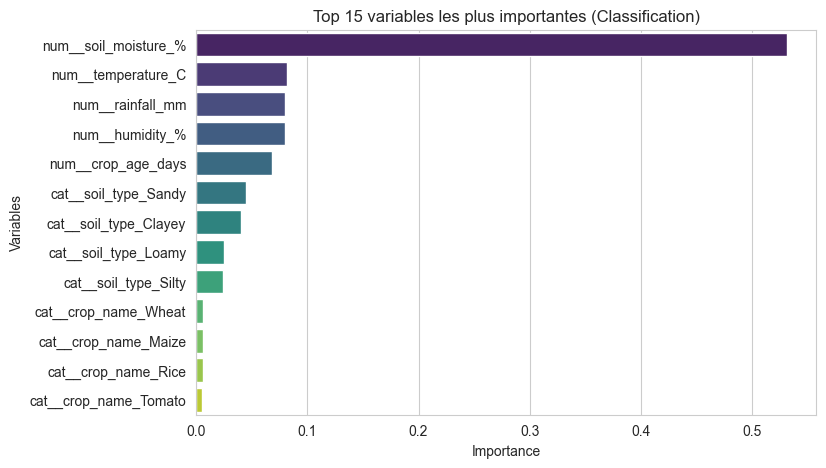

C:\Users\LENEVO\AppData\Local\Temp\ipykernel_18344\2274545508.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp_reg.values, y=imp_reg.index, palette="magma")


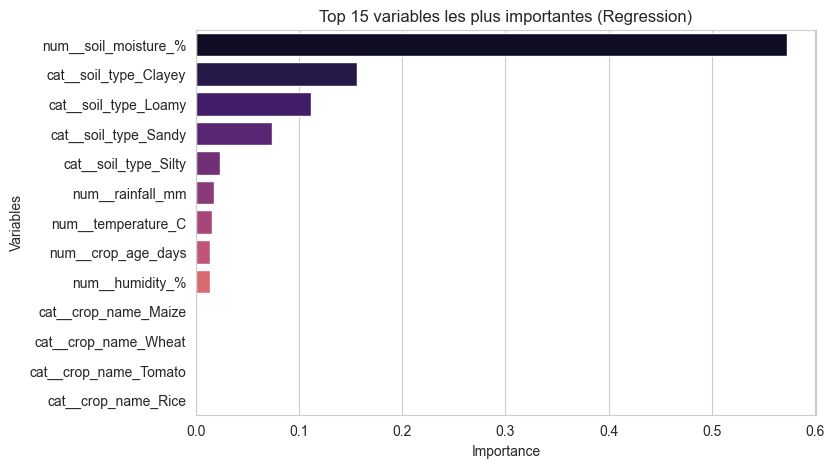

In [7]:
feature_names = clf_pipeline.named_steps["preprocess"].get_feature_names_out()

imp_clf = pd.Series(
    clf_pipeline.named_steps["model"].feature_importances_,
    index=feature_names,
).sort_values(ascending=False).head(15)

imp_reg = pd.Series(
    reg_pipeline.named_steps["model"].feature_importances_,
    index=feature_names,
).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
sns.barplot(x=imp_clf.values, y=imp_clf.index, palette="viridis")
plt.title("Top 15 variables les plus importantes (Classification)")
plt.xlabel("Importance")
plt.ylabel("Variables")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x=imp_reg.values, y=imp_reg.index, palette="magma")
plt.title("Top 15 variables les plus importantes (Regression)")
plt.xlabel("Importance")
plt.ylabel("Variables")
plt.show()

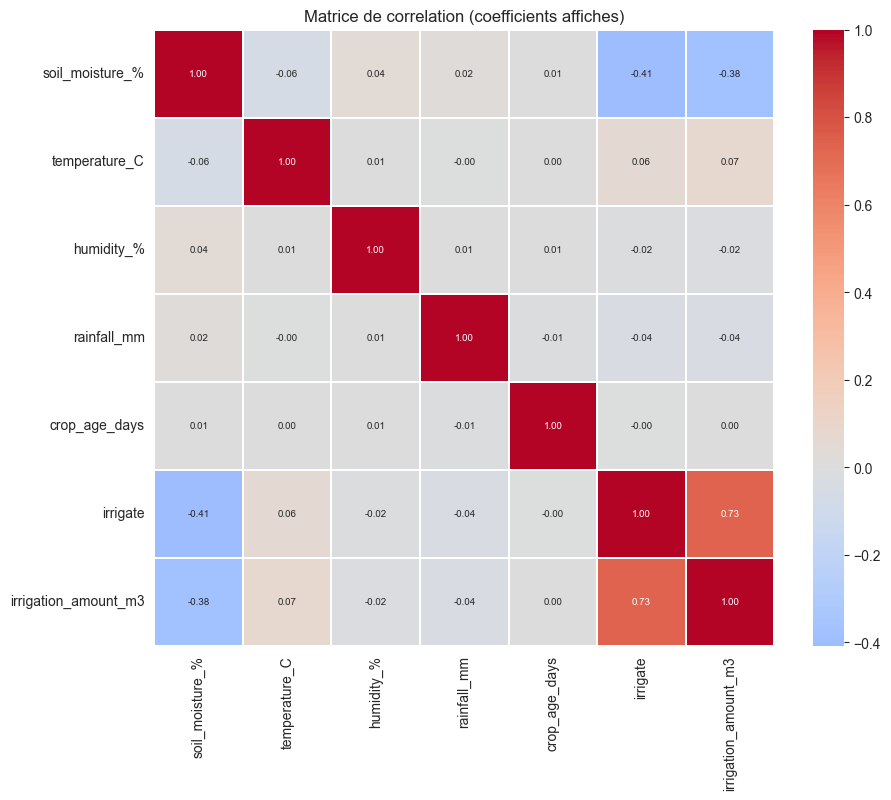

In [8]:
corr_cols = SENSOR_COLS + ["crop_age_days", "irrigate", "irrigation_amount_m3"]
corr_matrix = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    annot_kws={"size": 7},
)
plt.title("Matrice de correlation (coefficients affiches)")
plt.show()

In [9]:
import joblib
import json
from pathlib import Path

import numpy as np
from sklearn.tree import export_text


def _repo_root() -> Path:
    """Racine du projet (dossier contenant Smart_irrigation_dataset.csv)."""
    p = Path.cwd().resolve()
    for _ in range(10):
        if (p / "Smart_irrigation_dataset.csv").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError("Smart_irrigation_dataset.csv introuvable (lancez depuis le projet).")


out_dir = _repo_root() / "randomforest" / "models"
out_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(clf_pipeline, out_dir / "randomforest_classifier.joblib")
joblib.dump(reg_pipeline, out_dir / "randomforest_regressor.joblib")
joblib.dump(clf_pipeline.named_steps["preprocess"], out_dir / "randomforest_preprocessor.joblib")

pre = clf_pipeline.named_steps["preprocess"]
mm = pre.named_transformers_["num"].named_steps["scaler"]
ohe = pre.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = list(pre.transformers_[1][2])
(out_dir / "scaler_encoder_params.json").write_text(
    json.dumps(
        {
            "numeric_feature_names": list(pre.transformers_[0][2]),
            "data_min": mm.data_min_.tolist(),
            "data_max": mm.data_max_.tolist(),
            "scale": mm.scale_.tolist(),
            "min": mm.min_.tolist(),
            "onehot_feature_names_in": cat_feature_names,
            "onehot_categories": [np.asarray(c).tolist() for c in ohe.categories_],
        },
        indent=2,
    ),
    encoding="utf-8",
)

feat_names = clf_pipeline.named_steps["preprocess"].get_feature_names_out()
rf_rules = [
    "# Random Forest — regles simplifiees (premier arbre de chaque modele)",
    "",
    "## Classification (irrigate) — arbre[0]",
    export_text(clf_pipeline.named_steps["model"].estimators_[0], feature_names=feat_names),
    "",
    "## Regression (water_amount) — arbre[0]",
    export_text(reg_pipeline.named_steps["model"].estimators_[0], feature_names=feat_names),
    "",
]
(out_dir / "rf_rules.txt").write_text("\n".join(rf_rules), encoding="utf-8")

print("Sauvegarder", out_dir.resolve())
for p in sorted(out_dir.iterdir()):
    if p.is_file():
        print(f"  {p.name} ({p.stat().st_size // 1024} Ko)")

Sauvegarder C:\Users\LENEVO\Desktop\11master pf\randomforest\models
  randomforest_classifier.joblib (10965 Ko)
  randomforest_preprocessor.joblib (3 Ko)
  randomforest_regressor.joblib (3327 Ko)
  rf_rules.txt (52 Ko)
  scaler_encoder_params.json (0 Ko)
